# Load shoreline change and storm datasets

# All datasets must be on the same temporal scale.
The shoreline change is monthly, so storms must also be monthly.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load shoreline change data
shore = pd.read_csv(
    r"C:\Users\User\Documents\UC\DATA601\Erosion\erosion resources\shoreline_change_all_transects.csv"
)

shore["month"] = pd.to_datetime(shore["month"])

# Load cleaned storm datasets
ecan = pd.read_csv(
    r"C:\Users\User\Documents\UC\DATA601\Erosion\erosion resources\ECAN_wave_buoy_CLEANED.csv",
    parse_dates=["datetime"]
)

hindcast = pd.read_csv(
    r"C:\Users\User\Documents\UC\DATA601\Erosion\erosion resources\Nz_Hindcast_clean.csv",
    parse_dates=["datetime"]
)


# Aggregate shoreline change coast-wide (monthly)
Scientific rationale

Storms affect multiple transects simultaneously.
We therefore compute coast-wide mean erosion per month

In [3]:
shore_monthly = (
    shore.groupby("month")["shoreline_change"]
    .mean()
    .reset_index()
)

shore_monthly.rename(
    columns={"shoreline_change": "mean_shoreline_change"},
    inplace=True
)

shore_monthly.head()


,month,mean_shoreline_change
0,1999-07-01,NaN
1,1999-08-01,2.105517
2,1999-09-01,3.266016
3,1999-10-01,3.780714
4,1999-11-01,1.193659


# Aggregate storm metrics monthly
We are not interested in individual wave measurements, but in the storm climate each month.

Key storm metrics:

Number of storm hours

Maximum Hs

Mean storm Hs

Dominant storm direction

# ECAN buoy monthly storm metrics
Monthly storm aggregation (ECAN)

In [18]:
print(ecan.columns)

Index(['date', 'time', 'julian_date', 'Tpeak', 'Dp', 'DirSpread', 'Tm01',
       'Tm02', 'Hs', 'Qp', 'datetime', 'storm_flag', 'storm_group', 'month',
       'is_storm_raw', 'storm_event', 'storm_event_id'],
      dtype='object')


In [19]:
HS_THRESHOLD = 2.5

ecan['is_storm'] = ecan['Hs'] >= HS_THRESHOLD


In [20]:
ecan[['Hs', 'is_storm']].head()

,Hs,is_storm
0,1.05,False
1,1.04,False
2,0.96,False
3,1.62,False
4,1.74,False


In [21]:
ecan['month'] = ecan['datetime'].dt.to_period('M').dt.to_timestamp()

In [23]:
ecan_monthly = (
    ecan[ecan['storm_event']]   # use cleaned storm events
    .groupby('month')
    .agg(
        ecan_storm_hours=('Hs', 'count'),
        ecan_max_Hs=('Hs', 'max'),
        ecan_mean_Hs=('Hs', 'mean'),
        ecan_mean_dir=('Dp', 'mean')   # FIXED
    )
    .reset_index()
)

ecan_monthly.head()


,month,ecan_storm_hours,ecan_max_Hs,ecan_mean_Hs,ecan_mean_dir
0,1999-02-01,2,2.65,2.610000,182.905000
1,1999-03-01,3,2.82,2.703333,96.186667
2,1999-04-01,6,2.70,2.623333,108.608333
3,1999-05-01,5,3.74,2.870000,168.844000
4,1999-06-01,7,3.33,2.825714,181.901429


In [25]:
ecan_monthly.to_csv(r"C:\Users\User\Documents\UC\DATA601\Erosion\erosion resources\ECAN_buoy_monthly_storm_metrics.csv", index=False)

In [28]:
# Display the first few rows
ecan_monthly.head()

,month,ecan_storm_hours,ecan_max_Hs,ecan_mean_Hs,ecan_mean_dir
0,1999-02-01,2,2.65,2.610000,182.905000
1,1999-03-01,3,2.82,2.703333,96.186667
2,1999-04-01,6,2.70,2.623333,108.608333
3,1999-05-01,5,3.74,2.870000,168.844000
4,1999-06-01,7,3.33,2.825714,181.901429


# NZ Hindcast monthly storm metrics
 Monthly storm aggregation (hindcast)

In [29]:
hindcast["month"] = hindcast["datetime"].dt.to_period("M").dt.to_timestamp()

hindcast_monthly = (
    hindcast[hindcast["is_storm"] == True]
    .groupby("month")
    .agg(
        model_storm_hours=("Hsig", "count"),
        model_max_Hs=("Hsig", "max"),
        model_mean_Hs=("Hsig", "mean"),
        model_mean_dir=("Dir", "mean")
    )
    .reset_index()
)

hindcast_monthly.head()


C:\Users\User\AppData\Local\Temp\ipykernel_18796\1163807766.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  hindcast["month"] = hindcast["datetime"].dt.to_period("M").dt.to_timestamp()


,month,model_storm_hours,model_max_Hs,model_mean_Hs,model_mean_dir
0,1993-01-01,14,5.34715,4.489612,202.947500
1,1993-03-01,15,5.34617,4.631059,170.030960
2,1993-04-01,16,5.37032,4.738166,194.844125
3,1993-05-01,13,5.49149,4.639531,201.829000
4,1993-06-01,7,4.64572,4.279997,199.670571


# Merge storm metrics with shoreline change
Why this step matters

This creates a single analysis table linking:

Storm forcing → Coastal response

In [30]:
# Merge shoreline change with ECAN storm metrics
merged = shore_monthly.merge(
    ecan_monthly,
    on="month",
    how="left"
)

# Merge hindcast storm metrics
merged = merged.merge(
    hindcast_monthly,
    on="month",
    how="left"
)

merged.head()


,month,mean_shoreline_change,ecan_storm_hours,ecan_max_Hs,ecan_mean_Hs,ecan_mean_dir,model_storm_hours,model_max_Hs,model_mean_Hs,model_mean_dir
0,1999-07-01,NaN,10.0,3.22,2.694000,150.844000,20.0,6.1611,4.835027,148.519700
1,1999-08-01,2.105517,7.0,3.60,3.117143,177.682857,2.0,4.4776,4.375580,195.086000
2,1999-09-01,3.266016,2.0,3.62,3.160000,161.105000,7.0,4.5849,4.377566,197.312429
3,1999-10-01,3.780714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1999-11-01,1.193659,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# First diagnostic plot: Storm energy vs erosion
Why this plot is essential

This is the simplest test of storm–erosion coupling.

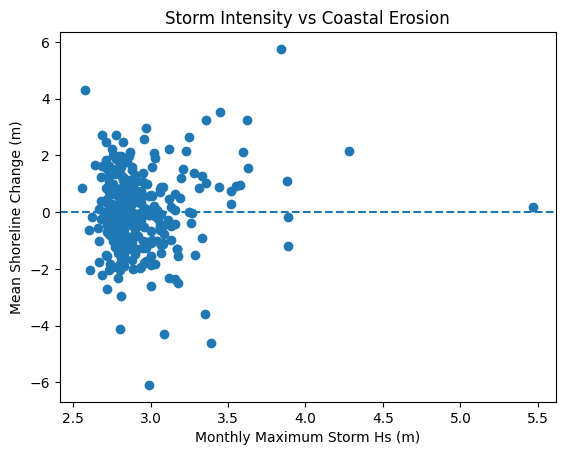

In [31]:
plt.figure()

plt.scatter(
    merged["ecan_max_Hs"],
    merged["mean_shoreline_change"]
)

plt.axhline(0, linestyle="--")
plt.xlabel("Monthly Maximum Storm Hs (m)")
plt.ylabel("Mean Shoreline Change (m)")
plt.title("Storm Intensity vs Coastal Erosion")

plt.show()


# Identify erosion-dominant storm months
Why this step matters

We now classify storm types that cause erosion, not just storms in general.

In [32]:
merged["erosion_month"] = merged["mean_shoreline_change"] < 0

merged[["month", "mean_shoreline_change", "ecan_max_Hs", "erosion_month"]].head()


,month,mean_shoreline_change,ecan_max_Hs,erosion_month
0,1999-07-01,NaN,3.22,False
1,1999-08-01,2.105517,3.60,False
2,1999-09-01,3.266016,3.62,False
3,1999-10-01,3.780714,NaN,False
4,1999-11-01,1.193659,NaN,False


# Storm direction vs erosion
Scientific importance

Direction encodes synoptic forcing and coastal exposure.

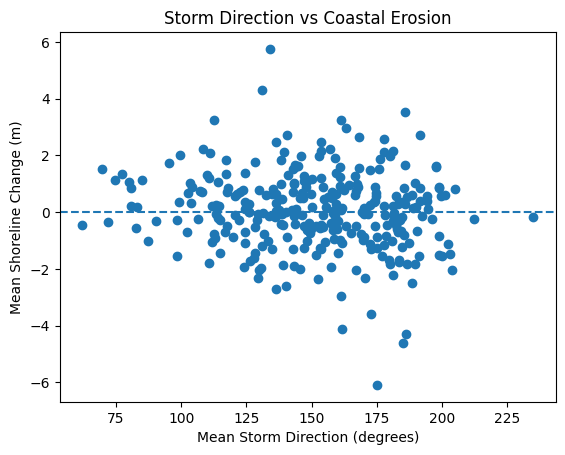

In [34]:
plt.figure()

plt.scatter(
    merged["ecan_mean_dir"],
    merged["mean_shoreline_change"]
)

plt.axhline(0, linestyle="--")
plt.xlabel("Mean Storm Direction (degrees)")
plt.ylabel("Mean Shoreline Change (m)")
plt.title("Storm Direction vs Coastal Erosion")

plt.show()


# Save merged storm–erosion dataset

In [35]:
output_path = r"C:\Users\User\Documents\UC\DATA601\Erosion\erosion resources\storm_shoreline_merged_monthly.csv"

merged.to_csv(output_path, index=False)

print("Saved merged storm–shoreline dataset to:")
print(output_path)


Saved merged storm–shoreline dataset to:
C:\Users\User\Documents\UC\DATA601\Erosion\erosion resources\storm_shoreline_merged_monthly.csv


In [36]:
# Define output path for NZ Hindcast monthly storm metrics
hindcast_out = r"C:\Users\User\Documents\UC\DATA601\Erosion\erosion resources\NZ_Hindcast_monthly_storm_metrics.csv"

# Save to CSV
hindcast_monthly.to_csv(hindcast_out, index=False)

print("Saved NZ Hindcast monthly storm metrics to:")
print(hindcast_out)

Saved NZ Hindcast monthly storm metrics to:
C:\Users\User\Documents\UC\DATA601\Erosion\erosion resources\NZ_Hindcast_monthly_storm_metrics.csv
